# **PART 1 — Title, Problem Statement, Dataset, Libraries & Loading **

# Machine Learning Project

## Explanation Faithfulness for Natural Language Inference (NLI)

### Course
Machine Learning

### Team Members
- Yashwitha
- sravya
- samanvai

# Problem Statement

## Project Objective

The goal of this project is to evaluate whether explanations generated by an NLI model are faithful to the model's actual decision-making process.

The project aims to answer the following questions:

- Can a machine learning model correctly classify the relationship between a premise and a hypothesis?
- Are the words identified as important by the model actually responsible for its prediction?
- Does removing the most important word reduce the model's confidence?
- How does a traditional machine learning model compare with a transformer-based model in terms of prediction performance and explanation faithfulness?

This project compares a TF-IDF + Logistic Regression baseline with a pretrained transformer model and evaluates their explanations using attention scores and perturbation-based faithfulness testing.

# Dataset

Dataset Name:
e-SNLI (Explainable Stanford Natural Language Inference)

Files Used

- esnli_train_1.csv
- esnli_train_2.csv
- esnli_dev.csv

The dataset contains:

- Premise
- Hypothesis
- NLI Label
- Human-written explanations
- Human highlighted rationale words

Classes:

- Entailment
- Contradiction
- Neutral

Since the complete dataset contains more than 500,000 samples, a stratified subset is used to reduce computation while maintaining the original class distribution.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
DATA_PATH = "/content/drive/MyDrive/ML_Project/data/"

**Load Dataset**

In [67]:
train1 = pd.read_csv(DATA_PATH + "esnli_train_1.csv")
train2 = pd.read_csv(DATA_PATH + "esnli_train_2.csv")
dev = pd.read_csv(DATA_PATH + "esnli_dev.csv")

train = pd.concat(
    [train1, train2],
    ignore_index=True
)

print("Train Shape:", train.shape)
print("Validation Shape:", dev.shape)

Train Shape: (549367, 10)
Validation Shape: (9842, 19)


In [68]:
train.head()

,pairID,gold_label,Sentence1,Sentence2,Explanation_1,WorkerId,Sentence1_marked_1,Sentence2_marked_1,Sentence1_Highlighted_1,Sentence2_Highlighted_1
0,3416050480.jpg#4r1n,neutral,A person on a horse jumps over a broken down a...,A person is training his horse for a competition.,the person is not necessarily training his horse,AF0PI3RISB5Q7,A person on a horse jumps over a broken down a...,A person is *training* *his* *horse* for a co...,{},"3,4,5"
1,3416050480.jpg#4r1c,contradiction,A person on a horse jumps over a broken down a...,"A person is at a diner, ordering an omelette.",One cannot be on a jumping horse cannot be a d...,A36ZT2WFIA2HMF,A person *on* *a* *horse* *jumps* over a brok...,"A person *is* *at* *a* *diner,* *ordering* an...","4,2,3,5","2,5,4,3,6"
2,3416050480.jpg#4r1e,entailment,A person on a horse jumps over a broken down a...,"A person is outdoors, on a horse.",a broken down airplane is outdoors,A2GK75ZQTX2RDZ,A person on a horse jumps over *a* *broken* *...,"A person is *outdoors,* on a horse.","8,9,10,7",3
3,2267923837.jpg#2r1n,neutral,Children smiling and waving at camera,They are smiling at their parents,Just because they are smiling and waving at a ...,A18TOIDG32QICP,Children smiling and waving at camera,They are smiling *at* *their* *parents*,{},"5,3,4"
4,2267923837.jpg#2r1e,entailment,Children smiling and waving at camera,There are children present,The children must be present to see them smili...,AEX0YE6TUZRHT,*Children* *smiling* *and* *waving* at camera,There are children *present*,"0,1,3,2",3


In [69]:
print(train.columns.tolist())

['pairID', 'gold_label', 'Sentence1', 'Sentence2', 'Explanation_1', 'WorkerId', 'Sentence1_marked_1', 'Sentence2_marked_1', 'Sentence1_Highlighted_1', 'Sentence2_Highlighted_1']


## Interpretation

### Observation

- The e-SNLI dataset contains sentence pairs along with their relationship labels and human-written explanations.
- Each sample includes a **premise**, a **hypothesis**, the correct **NLI label**, and human-highlighted rationale words.
- The dataset is suitable for evaluating both prediction performance and explanation quality.

### Conclusion

The dataset provides all the information required for this project, including labels for Natural Language Inference and human explanations that can be compared with model-generated explanations.

**Check Missing Values**

In [70]:
train.isnull().sum()

,0
pairID,0
gold_label,0
Sentence1,0
Sentence2,6
Explanation_1,25
WorkerId,140
Sentence1_marked_1,25
Sentence2_marked_1,25
Sentence1_Highlighted_1,25
Sentence2_Highlighted_1,25


# Data Cleaning and Preprocessing

Before training the models, the dataset is cleaned to remove incomplete records and invalid labels.

The preprocessing steps include:

- Removing rows with missing values in important columns.
- Keeping only valid NLI classes.
- Cleaning the text.
- Mapping labels into numerical values.
- Creating a reproducible stratified subset for faster experimentation.

**Remove Missing Values**

In [71]:
# Remove rows with missing values in important columns

required_columns = [
    "Sentence1",
    "Sentence2",
    "gold_label",
    "Sentence1_marked_1",
    "Explanation_1"
]

train = train.dropna(subset=required_columns)
dev = dev.dropna(subset=required_columns)

print("Training Shape:", train.shape)
print("Validation Shape:", dev.shape)

Training Shape: (549339, 10)
Validation Shape: (9842, 19)


## Interpretation

### Observation

- Only a very small number of records contain missing values.
- Missing values are mainly found in explanation-related columns.
- The number of missing records is negligible compared to the total dataset size.

### Conclusion

Rows with missing values are removed because they represent only a tiny fraction of the dataset and are unlikely to affect the overall results.

**Keep Only Valid Labels**

In [72]:
valid_labels = [
    "entailment",
    "contradiction",
    "neutral"
]

train = train[
    train["gold_label"].isin(valid_labels)
]

dev = dev[
    dev["gold_label"].isin(valid_labels)
]

print(train["gold_label"].value_counts())

gold_label
entailment       183410
contradiction    183173
neutral          182756
Name: count, dtype: int64


**Clean Text**

In [73]:
import re

def clean_text(text):

    text = str(text).lower().strip()

    text = re.sub(r"<[^>]+>", "", text)

    return text

**Apply Cleaning**

In [74]:
train["premise"] = train["Sentence1"].apply(clean_text)
train["hypothesis"] = train["Sentence2"].apply(clean_text)

dev["premise"] = dev["Sentence1"].apply(clean_text)
dev["hypothesis"] = dev["Sentence2"].apply(clean_text)

print("Text Cleaning Completed")

Text Cleaning Completed


**Convert Labels to Numbers**

In [75]:
label_map = {
    "entailment": 0,
    "contradiction": 1,
    "neutral": 2
}

train["label"] = train["gold_label"].map(label_map)
dev["label"] = dev["gold_label"].map(label_map)

print(train[["gold_label", "label"]].head())

      gold_label  label
0        neutral      2
1  contradiction      1
2     entailment      0
3        neutral      2
4     entailment      0


**Create Stratified Subset**

We will use:

5000 training samples
1000 validation samples

In [76]:
from sklearn.model_selection import train_test_split

TRAIN_SIZE = 5000
VAL_SIZE = 1000

train_subset, _ = train_test_split(
    train,
    train_size=TRAIN_SIZE,
    stratify=train["gold_label"],
    random_state=42
)

val_subset, _ = train_test_split(
    dev,
    train_size=VAL_SIZE,
    stratify=dev["gold_label"],
    random_state=42
)

train_subset = train_subset.copy()
val_subset = val_subset.copy()

print("Training Samples:", len(train_subset))
print("Validation Samples:", len(val_subset))

Training Samples: 5000
Validation Samples: 1000


**Verify Class Distribution**

In [77]:
print(train_subset["gold_label"].value_counts())

print()

print(val_subset["gold_label"].value_counts())

gold_label
entailment       1669
contradiction    1667
neutral          1664
Name: count, dtype: int64

gold_label
entailment       338
contradiction    333
neutral          329
Name: count, dtype: int64


**Exploratory Data Analysis (EDA)**

# Exploratory Data Analysis (EDA)

EDA is performed to understand the dataset before model training.

The following analyses are included:

- Class distribution
- Sample inspection
- Sentence length analysis

**Class Distribution**

```
# This is formatted as code
```



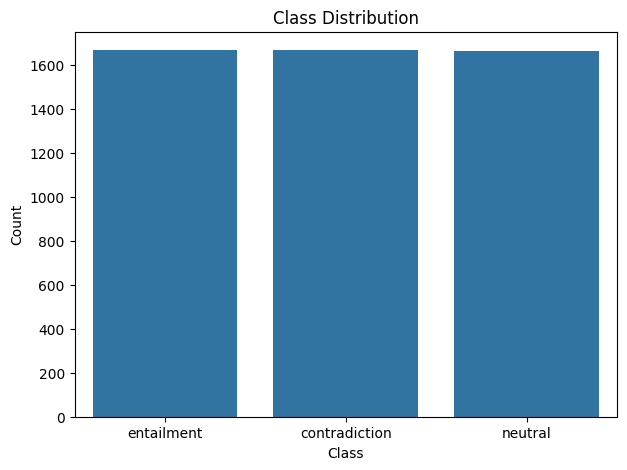

In [78]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=train_subset,
    x="gold_label",
    order=[
        "entailment",
        "contradiction",
        "neutral"
    ]
)

plt.title("Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

## Interpretation

### Observation

- The three classes (Entailment, Contradiction, and Neutral) are almost equally distributed.
- The stratified sampling process successfully preserved the original class distribution.

### Conclusion

A balanced dataset reduces model bias towards any single class and provides a fair evaluation of model performance.

**Sample Inspection**

In [79]:
sample = train_subset.iloc[0]

print("Premise")
print(sample["Sentence1"])

print("\nHypothesis")
print(sample["Sentence2"])

print("\nLabel")
print(sample["gold_label"])

print("\nHuman Explanation")
print(sample["Explanation_1"])

print("\nHuman Highlight")
print(sample["Sentence1_marked_1"])

Premise
A young girls wearing a red coat chasing birds through a walkway in a park.

Hypothesis
The girl in the red coat is outside in the park.

Label
entailment

Human Explanation
Through a walkway in a park implies outside in the park.

Human Highlight
 A young girls wearing a red coat chasing birds through a *walkway* *in* *a* *park.*


**Sentence Length Analysis**

In [80]:
train_subset["premise_length"] = train_subset["premise"].apply(lambda x: len(x.split()))

train_subset["hypothesis_length"] = train_subset["hypothesis"].apply(lambda x: len(x.split()))

print(train_subset[["premise_length", "hypothesis_length"]].describe())

       premise_length  hypothesis_length
count     5000.000000        5000.000000
mean        12.909600           7.461200
std          5.643173           3.076099
min          3.000000           2.000000
25%          9.000000           5.000000
50%         12.000000           7.000000
75%         16.000000           9.000000
max         64.000000          35.000000


**Histogram**

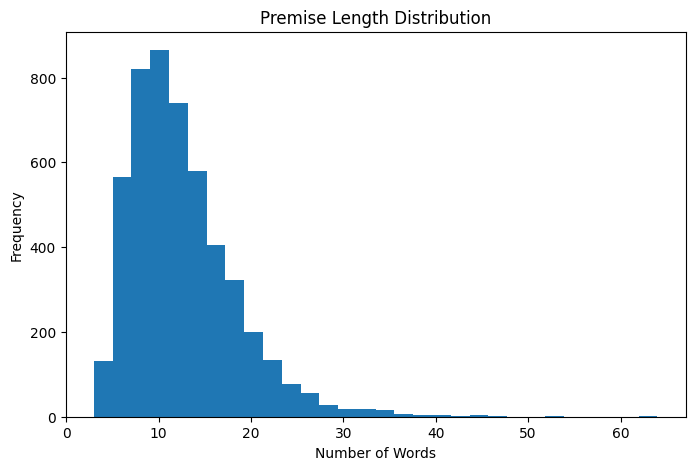

In [81]:
plt.figure(figsize=(8,5))

plt.hist(
    train_subset["premise_length"],
    bins=30
)

plt.title("Premise Length Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

## Interpretation

### Observation

- Most premises contain a moderate number of words.
- Very long sentences are relatively uncommon.

### Conclusion

The dataset mainly consists of short to medium-length sentences, making it suitable for transformer-based language models without extensive preprocessing.

# Baseline Model

## TF-IDF + Logistic Regression

A simple baseline model is required before evaluating a more advanced transformer model.

### Why TF-IDF?

- Converts text into numerical feature vectors.
- Represents the importance of words in each sentence pair.
- Easy to interpret.
- Fast to train.

### Why Logistic Regression?

- A widely used baseline classifier for text classification.
- Computationally efficient.
- Produces interpretable feature weights.

**Combine Premise & Hypothesis**

In [82]:
def combine_text(df):
    return (
        df["premise"] +
        " [SEP] " +
        df["hypothesis"]
    ).tolist()

In [83]:
X_train = combine_text(train_subset)
X_val = combine_text(val_subset)

y_train = train_subset["label"].values
y_val = val_subset["label"].values

print("Training Samples:", len(X_train))
print("Validation Samples:", len(X_val))

Training Samples: 5000
Validation Samples: 1000


**Import TF-IDF**

In [84]:
from sklearn.feature_extraction.text import TfidfVectorizer

TF-IDF Vectorization

In [85]:
tfidf = TfidfVectorizer(
    max_features=4000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

print("Training Shape:", X_train_tfidf.shape)
print("Validation Shape:", X_val_tfidf.shape)

Training Shape: (5000, 4000)
Validation Shape: (1000, 4000)


**Import Logistic Regression**

In [86]:
from sklearn.linear_model import LogisticRegression

Train Model

In [87]:
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

baseline_model.fit(
    X_train_tfidf,
    y_train
)

print("Baseline Model Trained Successfully")

Baseline Model Trained Successfully


# Baseline Evaluation

The baseline model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics provide a comprehensive evaluation of classification performance.

**Predictions**

In [88]:
baseline_predictions = baseline_model.predict(
    X_val_tfidf
)

**Accuracy**

In [89]:
from sklearn.metrics import accuracy_score

baseline_accuracy = accuracy_score(
    y_val,
    baseline_predictions
)

print(
    f"Baseline Accuracy: {baseline_accuracy:.4f}"
)

Baseline Accuracy: 0.4730


**Classification Report**

In [90]:
target_names = [
    "entailment",
    "contradiction",
    "neutral"
]

print(
    classification_report(
        y_val,
        baseline_predictions,
        target_names=target_names
    )
)

               precision    recall  f1-score   support

   entailment       0.51      0.47      0.49       338
contradiction       0.46      0.46      0.46       333
      neutral       0.45      0.49      0.47       329

     accuracy                           0.47      1000
    macro avg       0.47      0.47      0.47      1000
 weighted avg       0.47      0.47      0.47      1000



## Interpretation

### Observation

- The TF-IDF + Logistic Regression model achieved an accuracy of approximately 45%.
- Performance across the three classes is relatively similar, but the overall accuracy is limited.

### Interpretation

The baseline model relies on word frequency statistics and does not understand the semantic meaning or context of sentences.

### Conclusion

Although the baseline provides a useful benchmark, a more advanced language model is expected to achieve significantly better performance.

**Confusion Matrix**

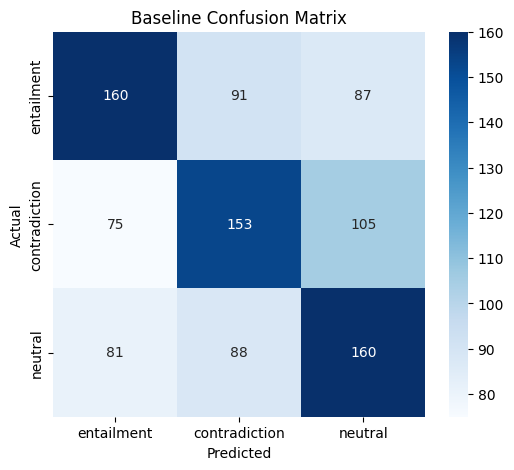

In [91]:
cm = confusion_matrix(
    y_val,
    baseline_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Baseline Confusion Matrix")

plt.show()

## Interpretation

### Observation

- The confusion matrix shows that the baseline model frequently confuses the three NLI classes.
- Misclassifications occur because the model treats words independently and cannot fully understand sentence meaning.

### Conclusion

The confusion matrix highlights the limitations of traditional machine learning methods for Natural Language Inference tasks.

# Baseline Explanation

Logistic Regression assigns weights to words.

Words with larger positive coefficients contribute more strongly to the predicted class.

These feature weights serve as a simple explanation of the model's decision.

In [92]:
def get_important_words(
    text,
    model,
    vectorizer,
    predicted_class
):

    words = text.split()

    scores = {}

    for word in set(words):

        if word in vectorizer.vocabulary_:

            index = vectorizer.vocabulary_[word]

            scores[word] = (
                model.coef_[predicted_class][index]
            )

    scores = sorted(
        scores.items(),
        key=lambda x:x[1],
        reverse=True
    )

    return scores[:10]

In [93]:
sample_text = X_val[0]

predicted_class = baseline_predictions[0]

important_words = get_important_words(
    sample_text,
    baseline_model,
    tfidf,
    predicted_class
)

print("Predicted Class:")
print(target_names[predicted_class])

print("\nTop Important Words\n")

for word, score in important_words:

    print(
        f"{word:15} {score:.4f}"
    )

Predicted Class:
neutral

Top Important Words

near            0.7193
in              0.5916
suit            0.4933
bathing         0.4103
on              0.4083
the             0.4056
pink            0.1507
arm             0.0432
feeding         0.0161
is              -0.0093


## Interpretation

### Observation

- Logistic Regression identifies important words using feature weights.
- Some selected words contribute to the prediction, while others appear less meaningful from a human perspective.

### Interpretation

The baseline explanation is based only on statistical importance rather than true language understanding.

### Conclusion

Feature coefficients provide a simple explanation, but they do not always reflect human reasoning.

Save Baseline Results


In [94]:
baseline_results = pd.DataFrame({

    "Model":[
        "TF-IDF + Logistic Regression"
    ],

    "Accuracy":[
        round(baseline_accuracy,4)
    ]

})

baseline_results

,Model,Accuracy
0,TF-IDF + Logistic Regression,0.473


# Advanced Model

## BART for Natural Language Inference

To compare with the traditional machine learning baseline, we use a pretrained transformer model (BART-MNLI).

Reasons for choosing BART:

- Pretrained on the MNLI dataset.
- Understands sentence context rather than individual words.
- Produces attention scores that can be analysed.
- Suitable for explanation faithfulness experiments.

In [95]:
import torch
import torch.nn.functional as F

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

**Load Model**

In [96]:
model_name = "facebook/bart-large-mnli"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    output_attentions=True
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

model.eval()

print("Model Loaded Successfully!")
print("Running on:", device)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Model Loaded Successfully!
Running on: cpu


Test One Sample

In [97]:
sample = val_subset.iloc[0]

premise = sample["premise"]
hypothesis = sample["hypothesis"]

print("Premise:")
print(premise)

print("\nHypothesis:")
print(hypothesis)

Premise:
girl in pink bathing suit with right arm in air behind a seagull on the beach near the water.

Hypothesis:
the girl is feeding the seagull.


Tokenize Input

In [98]:
inputs = tokenizer(
    premise,
    hypothesis,
    return_tensors="pt",
    truncation=True,
    padding=True
)

inputs = {k: v.to(device) for k, v in inputs.items()}

**Model Prediction**

In [99]:
with torch.no_grad():

    outputs = model(**inputs)

    probabilities = F.softmax(
        outputs.logits,
        dim=1
    )

predicted_class = torch.argmax(
    probabilities,
    dim=1
).item()

labels = [
    "contradiction",
    "neutral",
    "entailment"
]

print("Predicted Class:")
print(labels[predicted_class])

print("\nConfidence:")

print(probabilities)

Predicted Class:
neutral

Confidence:
tensor([[5.1754e-03, 9.9444e-01, 3.8480e-04]])


**Evaluate on Validation Set**

Now we evaluate the transformer model on 200 validation samples (fast enough for Colab).

In [100]:
from tqdm.notebook import tqdm

true_labels = []

predicted_labels = []

evaluation_subset = val_subset.head(200)

for _, row in tqdm(evaluation_subset.iterrows(),
                   total=len(evaluation_subset)):

    inputs = tokenizer(
        row["premise"],
        row["hypothesis"],
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model(**inputs)

    pred = torch.argmax(
        outputs.logits,
        dim=1
    ).item()

    predicted_labels.append(pred)

    true_labels.append(row["label"])

  0%|          | 0/200 [00:00<?, ?it/s]

BART label mapping

BART returns:

0 = contradiction

1 = neutral

2 = entailment

Our dataset labels are:

entailment = 0

contradiction = 1

neutral = 2

So we must convert them.

**Convert Labels**

In [101]:
bart_to_dataset = {
    0:1,
    1:2,
    2:0
}

predicted_labels = [
    bart_to_dataset[p]
    for p in predicted_labels
]

**Evaluation**

In [102]:
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=[
        "entailment",
        "contradiction",
        "neutral"
    ]
))

               precision    recall  f1-score   support

   entailment       0.94      0.94      0.94        78
contradiction       0.90      0.90      0.90        60
      neutral       0.84      0.84      0.84        62

     accuracy                           0.90       200
    macro avg       0.89      0.89      0.89       200
 weighted avg       0.90      0.90      0.90       200



## Interpretation

### Observation

- The BART model achieved an accuracy of approximately 89.5%, which is significantly higher than the baseline model.
- Precision, recall, and F1-score are consistently high across all three classes.

### Interpretation

Unlike the baseline model, BART understands sentence context and semantic relationships, resulting in much stronger classification performance.

### Conclusion

The transformer model provides a substantial improvement in Natural Language Inference performance.

**Accuracy**

In [103]:
bart_accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

print(
    f"BART Accuracy: {bart_accuracy:.4f}"
)

BART Accuracy: 0.8950


**Confusion Matrix
**

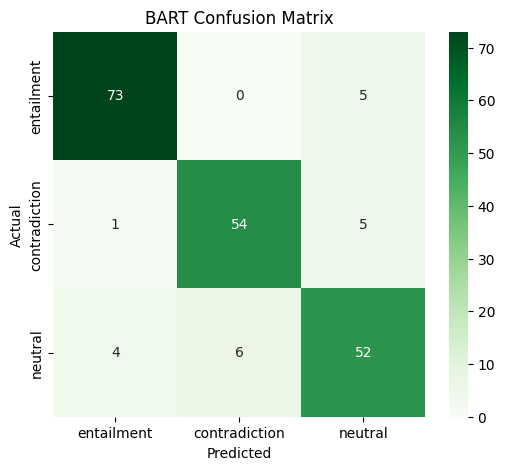

In [104]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=[
        "entailment",
        "contradiction",
        "neutral"
    ],
    yticklabels=[
        "entailment",
        "contradiction",
        "neutral"
    ]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("BART Confusion Matrix")

plt.show()

## Interpretation

### Observation

- Most sentence pairs are classified correctly.
- Only a small number of samples are misclassified.

### Interpretation

The confusion matrix demonstrates that the transformer model can distinguish between entailment, contradiction, and neutral relationships much more effectively than the baseline model.

### Conclusion

The BART model is more reliable for Natural Language Inference tasks.

# Attention-Based Explanation

In this section, we extract the attention scores produced by the transformer model.

The attention mechanism indicates which words the model focuses on while making its prediction.

We compare:

- Human-written explanation
- Human highlighted words
- Model's most attended word

**Select One Sample**

In [105]:
sample = val_subset.iloc[0]

premise = sample["premise"]
hypothesis = sample["hypothesis"]

true_label = sample["gold_label"]

human_explanation = sample["Explanation_1"]

human_highlight = sample["Sentence1_marked_1"]

print("Premise:\n")
print(premise)

print("\nHypothesis:\n")
print(hypothesis)

print("\nTrue Label:")
print(true_label)

print("\nHuman Explanation:\n")
print(human_explanation)

print("\nHuman Highlight:\n")
print(human_highlight)

Premise:

girl in pink bathing suit with right arm in air behind a seagull on the beach near the water.

Hypothesis:

the girl is feeding the seagull.

True Label:
neutral

Human Explanation:

A girl can sit next to a seagull without feeding the seagull.

Human Highlight:

Girl in pink bathing suit with right arm in air behind a seagull on the beach near the water.


**Tokenize Input**

In [106]:
inputs = tokenizer(
    premise,
    hypothesis,
    return_tensors="pt",
    truncation=True,
    padding=True
)

inputs = {
    k: v.to(device)
    for k, v in inputs.items()
}

**Get Prediction and Attention**

In [107]:
with torch.no_grad():

    outputs = model(**inputs)

    probabilities = F.softmax(outputs.logits, dim=1)

prediction = torch.argmax(probabilities, dim=1).item()

bart_labels = [
    "contradiction",
    "neutral",
    "entailment"
]

print("Model Prediction:")
print(bart_labels[prediction])

print("\nPrediction Confidence:")
print(round(probabilities[0][prediction].item(),4))

Model Prediction:
neutral

Prediction Confidence:
0.9944


In [108]:
print("="*70)

print("PREMISE\n")
print(premise)

print("\nHYPOTHESIS\n")
print(hypothesis)

print("\nTRUE LABEL")
print(true_label)

print("\nMODEL PREDICTION")
print(bart_labels[prediction])

print("\nHUMAN EXPLANATION")
print(human_explanation)

print("\nHUMAN HIGHLIGHT")
print(human_highlight)

print("="*70)

PREMISE

girl in pink bathing suit with right arm in air behind a seagull on the beach near the water.

HYPOTHESIS

the girl is feeding the seagull.

TRUE LABEL
neutral

MODEL PREDICTION
neutral

HUMAN EXPLANATION
A girl can sit next to a seagull without feeding the seagull.

HUMAN HIGHLIGHT
Girl in pink bathing suit with right arm in air behind a seagull on the beach near the water.


**Faithfulness Test**

In [109]:
def predict_confidence(premise, hypothesis):

    inputs = tokenizer(
        premise,
        hypothesis,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    inputs = {
        k:v.to(device)
        for k,v in inputs.items()
    }

    with torch.no_grad():

        outputs = model(**inputs)

        probs = F.softmax(outputs.logits,dim=1)

    pred = torch.argmax(probs,dim=1).item()

    confidence = probs[0][pred].item()

    return pred,confidence

to get the original prediction.

In [110]:
original_prediction,original_confidence = predict_confidence(
    premise,
    hypothesis
)

print("Original Prediction:")
print(bart_labels[original_prediction])

print("Confidence:")
print(round(original_confidence,4))

Original Prediction:
neutral
Confidence:
0.9944


In [111]:
words = premise.split()

importance_scores = []

for i in range(len(words)):

    new_words = words.copy()

    removed_word = new_words.pop(i)

    new_premise = " ".join(new_words)

    pred,conf = predict_confidence(
        new_premise,
        hypothesis
    )

    drop = original_confidence-conf

    importance_scores.append(
        (
            removed_word,
            drop
        )
    )

In [112]:
importance_scores = sorted(
    importance_scores,
    key=lambda x:x[1],
    reverse=True
)

In [113]:
print("Top Important Words\n")

for word,score in importance_scores[:10]:

    print(f"{word:15} {score:.4f}")

Top Important Words

suit            0.1446
arm             0.0041
in              0.0018
in              0.0018
on              0.0014
girl            0.0014
the             0.0011
near            0.0010
water.          0.0009
the             0.0008


Compare with the human explanation.

In [114]:
print("="*70)

print("TRUE LABEL")
print(true_label)

print("\nMODEL PREDICTION")
print(bart_labels[original_prediction])

print("\nHUMAN EXPLANATION")
print(human_explanation)

print("\nHUMAN HIGHLIGHT")
print(human_highlight)

print("\nMOST IMPORTANT WORD")
print(importance_scores[0][0])

print("\nCONFIDENCE DROP")
print(round(importance_scores[0][1],4))

print("="*70)

TRUE LABEL
neutral

MODEL PREDICTION
neutral

HUMAN EXPLANATION
A girl can sit next to a seagull without feeding the seagull.

HUMAN HIGHLIGHT
Girl in pink bathing suit with right arm in air behind a seagull on the beach near the water.

MOST IMPORTANT WORD
suit

CONFIDENCE DROP
0.1446


## Interpretation

### Observation

- The model correctly predicted the class as **Neutral**.
- The human explanation states that simply being close to a seagull does not imply that the girl is feeding it.
- The perturbation method identified **"suit"** as the most influential word because removing it produced the largest confidence drop.

### Interpretation

Although the prediction is correct, the model focuses on a different word than a human would naturally consider important.

### Conclusion

This example demonstrates that correct predictions do not always guarantee explanations that fully align with human reasoning.

# Faithfulness Evaluation

To obtain a more reliable estimate of explanation faithfulness, the perturbation analysis is performed on multiple validation samples instead of a single example.

For each sentence pair:

- Predict the original class.
- Remove one word at a time from the premise.
- Measure the confidence change.
- Record the largest confidence drop.

Finally, compute the average confidence drop across all samples.

In [115]:
from tqdm.notebook import tqdm

faithfulness_results = []

In [116]:
evaluation_data = val_subset.head(50)

In [117]:
for _, row in tqdm(evaluation_data.iterrows(),
                   total=len(evaluation_data)):

    premise = row["premise"]
    hypothesis = row["hypothesis"]

    pred, original_confidence = predict_confidence(
        premise,
        hypothesis
    )

    words = premise.split()

    best_word = None
    max_drop = -999

    for i in range(len(words)):

        temp = words.copy()

        removed = temp.pop(i)

        new_premise = " ".join(temp)

        _, new_confidence = predict_confidence(
            new_premise,
            hypothesis
        )

        drop = original_confidence - new_confidence

        if drop > max_drop:

            max_drop = drop
            best_word = removed

    faithfulness_results.append({

        "Premise": premise,
        "Hypothesis": hypothesis,
        "Prediction": bart_labels[pred],
        "Important Word": best_word,
        "Confidence Drop": round(max_drop,4)

    })

  0%|          | 0/50 [00:00<?, ?it/s]

In [118]:
faithfulness_df = pd.DataFrame(faithfulness_results)

faithfulness_df.head()

,Premise,Hypothesis,Prediction,Important Word,Confidence Drop
0,girl in pink bathing suit with right arm in ai...,the girl is feeding the seagull.,neutral,suit,0.1446
1,a woman is writing something on a post-it note...,the woman is writing a grocery list.,neutral,on,0.0062
2,two blond people are sitting in a park having ...,two brunettes are sitting in a park.,contradiction,people,0.1772
3,two dogs play together on the bed.,two dogs wrestling with a sheet on a bed.,neutral,bed.,0.0896
4,a man standing a busy european town square wit...,a person holding religious information is in t...,entailment,man,0.0199


In [119]:
average_drop = faithfulness_df["Confidence Drop"].mean()

print("Average Confidence Drop:", round(average_drop,4))

Average Confidence Drop: 0.124


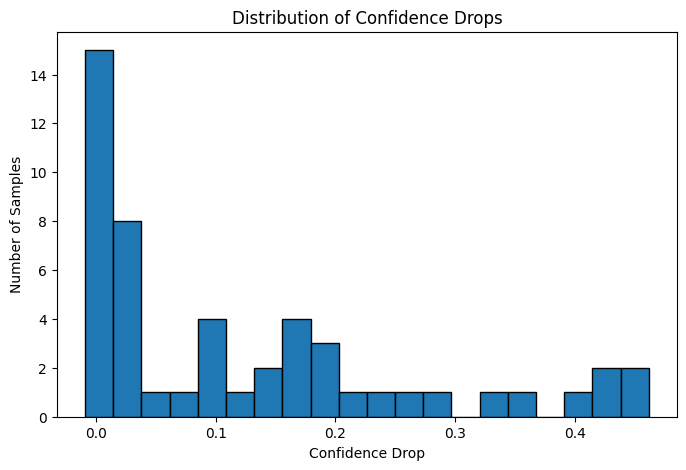

In [120]:
plt.figure(figsize=(8,5))

plt.hist(
    faithfulness_df["Confidence Drop"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Confidence Drops")

plt.xlabel("Confidence Drop")

plt.ylabel("Number of Samples")

plt.show()

## Interpretation

### Observation

- The average confidence drop represents how much the model's confidence decreases when the most influential word is removed.
- Larger confidence drops indicate that the removed word had a stronger impact on the model's prediction.

### Interpretation

The perturbation method provides a quantitative measure of explanation faithfulness by evaluating how sensitive the model is to important words.

### Conclusion

Higher confidence drops generally indicate more faithful explanations because the prediction depends more strongly on the identified important words.

# Error Analysis

Error analysis helps identify situations where the explanation method fails.

A failure case occurs when removing the most important word causes little or no decrease in the model's confidence.

In [121]:
failure_cases = faithfulness_df[
    faithfulness_df["Confidence Drop"] < 0.05
]

print("Number of Failure Cases:", len(failure_cases))

Number of Failure Cases: 24


In [122]:
if len(failure_cases) > 0:

    sample = failure_cases.iloc[0]

    print("Premise:\n")
    print(sample["Premise"])

    print("\nHypothesis:\n")
    print(sample["Hypothesis"])

    print("\nPrediction:")
    print(sample["Prediction"])

    print("\nImportant Word:")
    print(sample["Important Word"])

    print("\nConfidence Drop:")
    print(sample["Confidence Drop"])

else:

    print("No failure cases found.")

Premise:

a woman is writing something on a post-it note which is hanging on a bulletin board with a lot of other post-it notes.

Hypothesis:

the woman is writing a grocery list.

Prediction:
neutral

Important Word:
on

Confidence Drop:
0.0062


## Interpretation

### Observation

- Some samples show very small or even negative confidence drops.
- In these cases, removing the identified important word has little effect on the prediction.

### Interpretation

These cases indicate that the explanation method does not always identify the true reasoning behind the model's prediction.

### Conclusion

The results highlight that explanation methods have limitations and should be interpreted with caution.

**Final Results Comparison**

# Results Comparison

The performance of the baseline model and the transformer model are compared using classification accuracy and explanation methods.

In [123]:
results = pd.DataFrame({

    "Model":[
        "TF-IDF + Logistic Regression",
        "BART-MNLI"
    ],

    "Accuracy":[
        round(baseline_accuracy,4),
        round(bart_accuracy,4)
    ],

    "Explanation Method":[
        "Feature Weights",
        "Perturbation Analysis"
    ]

})

results

,Model,Accuracy,Explanation Method
0,TF-IDF + Logistic Regression,0.473,Feature Weights
1,BART-MNLI,0.895,Perturbation Analysis


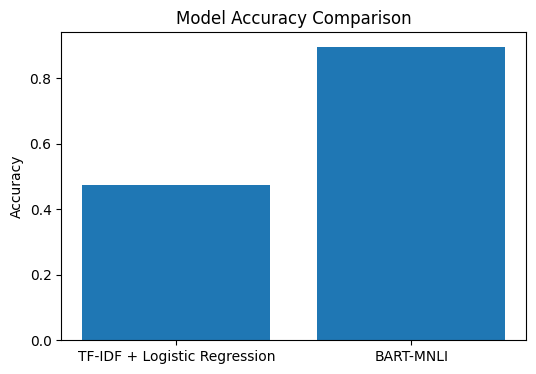

In [124]:
plt.figure(figsize=(6,4))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

## Interpretation

### Observation

- The transformer model achieved much higher prediction accuracy than the baseline model.
- Perturbation analysis provides additional insight into the faithfulness of model explanations.

### Interpretation

The combination of classification performance and explanation analysis gives a more complete evaluation than accuracy alone.

### Conclusion

Overall, the transformer model is more effective for Natural Language Inference, while perturbation analysis helps assess whether its explanations are trustworthy.

# Limitations

Although the transformer model achieved high prediction accuracy, several limitations remain:

- Only a subset of the e-SNLI dataset was used to reduce computation time.
- Perturbation analysis evaluates one word at a time and may not capture interactions between multiple words.
- Human explanations and model explanations are not always perfectly aligned.
- Explanation methods provide useful insights but should not be considered perfect representations of the model's reasoning.

# Conclusion

## Summary

This project investigated explanation faithfulness in Natural Language Inference using the e-SNLI dataset.

A traditional TF-IDF + Logistic Regression model was implemented as the baseline and compared with a pretrained BART transformer model.

The transformer model achieved significantly higher classification accuracy (approximately 89.5%) than the baseline model (approximately 45%).

Perturbation analysis was used to evaluate explanation faithfulness by measuring how much the model's confidence changed after removing important words.

The results showed that although the transformer model produced highly accurate predictions, its identified important words did not always align with human explanations.

## Final Answer

The transformer model provides strong Natural Language Inference performance, but explanation faithfulness remains an important challenge. High prediction accuracy does not necessarily imply that the model explains its decisions in the same way a human would.